# BÀI TẬP: TITANIC
**Nguồn:** kaggle.com/c/titanic (891 dòng)


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [2]:
print('So cot , so dong:', df.shape)
df.info()


So cot , so dong: (891, 15)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


## A.2. Missing values & Duplicate data

In [3]:
print("mising values:", df.isnull().sum())
print("Duplicate :", df.duplicated().sum())


mising values: survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64
Duplicate : 107


## A.3. Invalid values

In [4]:
invalid_fare = df[df['fare'] <= 0]
invalid_age = df[(df['age'] <= 0) | (df['age'] > 100)]
invalid_adult = df[(df['age'] < 16) & (df['adult_male'] == True)]
valid_sex = ['male', 'female']
invalid_sex = df[~df['sex'].isin(valid_sex)]

print(f"Số vé <= 0: {len(invalid_fare)}")
print(f"Số tuổi bất thường: {len(invalid_age)}")
print(f"Lỗi logic adult_male: {len(invalid_adult)}")

Số vé <= 0: 15
Số tuổi bất thường: 0
Lỗi logic adult_male: 0


## A.4. Create a new column
Tạo cột `family_size` = sibsp + parch + 1.

In [5]:
df['family_size'] = df['sibsp'] + df['parch'] + 1
print(df[['sibsp', 'parch', 'family_size', 'alone']].head())


   sibsp  parch  family_size  alone
0      1      0            2  False
1      1      0            2  False
2      0      0            1   True
3      1      0            2  False
4      0      0            1   True


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [7]:
num_cols = ['age', 'fare', 'family_size', 'sibsp', 'parch']

mean_vals = df[num_cols].mean()
median_vals = df[num_cols].median()
mode_vals = df[num_cols].mode().iloc[0] # Lấy giá trị mode đầu tiên

central_tendency = pd.DataFrame({
    'Mean (Trung bình)': mean_vals,
    'Median (Trung vị)': median_vals,
    'Mode (Yếu vị)': mode_vals
}).round(2)

print(central_tendency)

             Mean (Trung bình)  Median (Trung vị)  Mode (Yếu vị)
age                      29.70              28.00          24.00
fare                     32.20              14.45           8.05
family_size               1.90               1.00           1.00
sibsp                     0.52               0.00           0.00
parch                     0.38               0.00           0.00


## Group 2 — Dispersion

In [9]:
num_cols = ['age', 'fare', 'family_size']

# 2. Tính các chỉ số độ phân tán
dispersion = pd.DataFrame({
    'Var': df[num_cols].var(),
    'Std ': df[num_cols].std(),
    'Min': df[num_cols].min(),
    'Max': df[num_cols].max(),
    'Range': df[num_cols].max() - df[num_cols].min(),
    'IQR': df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25)
}).round(2)

print(dispersion)

                 Var   Std    Min     Max   Range    IQR
age           211.02  14.53  0.42   80.00   79.58  17.88
fare         2469.44  49.69  0.00  512.33  512.33  23.09
family_size     2.60   1.61  1.00   11.00   10.00   1.00


## Group 3 — Location and Shape

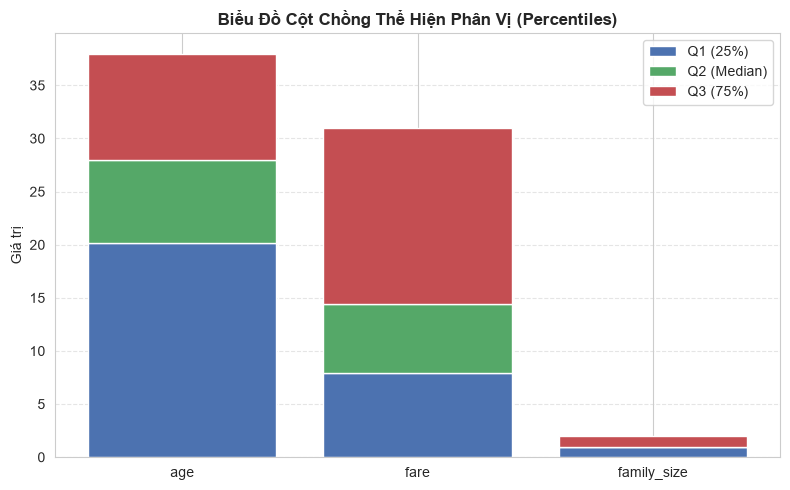

In [13]:
num_cols = ['age', 'fare', 'family_size']
percentiles = df[num_cols].quantile([0.25, 0.50, 0.75, 0.90, 0.99])
skewness = df[num_cols].skew()
kurtosis = df[num_cols].kurt()

# 3. Tổng hợp bảng Location & Shape
shape_df = pd.DataFrame({
    'Q1 ': percentiles.loc[0.25],
    'Q2 ': percentiles.loc[0.50],
    'Q3 ': percentiles.loc[0.75],
    'P90 ': percentiles.loc[0.90],
    'P99 ': percentiles.loc[0.99],
    'Skewness ': skewness,
    'Kurtosis ': kurtosis
}).round(2)
q1 = percentiles.loc[0.25]
q2_diff = percentiles.loc[0.50] - percentiles.loc[0.25]
q3_diff = percentiles.loc[0.75] - percentiles.loc[0.50]

# 2. Vẽ biểu đồ cột chồng
plt.figure(figsize=(8, 5))
plt.bar(num_cols, q1, label='Q1 (25%)', color='#4C72B0')
plt.bar(num_cols, q2_diff, bottom=q1, label='Q2 (Median)', color='#55A868')
plt.bar(num_cols, q3_diff, bottom=percentiles.loc[0.50], label='Q3 (75%)', color='#C44E52')

plt.title('Biểu Đồ Cột Chồng Thể Hiện Phân Vị (Percentiles)', fontweight='bold')
plt.ylabel('Giá trị')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Hạng vé nào có tỷ lệ sống sót cao nhất, chênh lệch bao nhiêu so với hạng thấp nhất?

In [ ]:
pclass_survived = df.groupby('pclass')['survived'].agg(
    Total='count',
    Survived='sum',
    Rate=lambda x: x.mean() * 100
).round(2)

print(pclass_survived)

rate_class1 = pclass_survived.loc[1, 'Rate']
rate_class3 = pclass_survived.loc[3, 'Rate']
diff = round(rate_class1 - rate_class3, 2)
print(f"\nChênh lệch giữa Class 1 và Class 3: {diff}%")

        Total  Survived   Rate
pclass                        
1         216       136  62.96
2         184        87  47.28
3         491       119  24.24

Chênh lệch giữa Class 1 và Class 3: 38.72%


## Câu hỏi 2: Giới tính hay hạng vé ảnh hưởng đến sống sót mạnh hơn?

In [16]:
sex_rate = df.groupby('sex')['survived'].mean() * 100

# 2. Tính tỷ lệ sống sót theo Hạng vé
pclass_rate = df.groupby('pclass')['survived'].mean() * 100

# 3. Xem bảng kết hợp cả 2 yếu tố
cross_rate = pd.crosstab(df['sex'], df['pclass'], values=df['survived'], aggfunc='mean') * 100

print("--- Tỷ lệ theo Giới tính ---")
print(sex_rate.round(2))
print("\n--- Tỷ lệ theo Hạng vé ---")
print(pclass_rate.round(2))
print("\n--- Bảng kết hợp Sex & Pclass (%) ---")
print(cross_rate.round(2))
print("\nNhận xét: Tỷ lệ sống sót cao hơn đáng kể ở nữ giới so với nam giới, và hành khách ở hạng vé cao (Class 1) có tỷ lệ sống sót cao hơn nhiều so với hạng vé thấp (Class 3). Bảng kết hợp cho thấy sự khác biệt rõ rệt trong tỷ lệ sống sót giữa các nhóm giới tính và hạng vé.")


--- Tỷ lệ theo Giới tính ---
sex
female    74.20
male      18.89
Name: survived, dtype: float64

--- Tỷ lệ theo Hạng vé ---
pclass
1    62.96
2    47.28
3    24.24
Name: survived, dtype: float64

--- Bảng kết hợp Sex & Pclass (%) ---
pclass      1      2      3
sex                        
female  96.81  92.11  50.00
male    36.89  15.74  13.54

Nhận xét: Tỷ lệ sống sót cao hơn đáng kể ở nữ giới so với nam giới, và hành khách ở hạng vé cao (Class 1) có tỷ lệ sống sót cao hơn nhiều so với hạng vé thấp (Class 3). Bảng kết hợp cho thấy sự khác biệt rõ rệt trong tỷ lệ sống sót giữa các nhóm giới tính và hạng vé.


## Câu hỏi 3: Vé đắt hơn có thực sự sống sót cao hơn không?

In [18]:
fare_summary = df.groupby('survived')['fare'].describe().round(2)
print("--- Thống kê Fare theo Nhóm Sống sót ---")
print(fare_summary[['mean', '50%', 'min', 'max']])

# 2. Chia giá vé thành các nhóm (Quartiles) để xem tỷ lệ sống sót
df['fare_group'] = pd.qcut(df['fare'], q=4, labels=['Rất rẻ (Q1)', 'Rẻ (Q2)', 'Trung bình (Q3)', 'Đắt (Q4)'])
fare_survival = df.groupby('fare_group', observed=False)['survived'].agg(
    Total='count',
    Survived='sum',
    Rate=lambda x: x.mean() * 100
).round(2)

print("\n--- Tỷ lệ Sống sót theo Nhóm Giá vé ---")
print(fare_survival)
print("\nNhận xét: Bảng trên cho thấy tỷ lệ sống sót theo các nhóm giá vé. Nhóm giá vé cao (Q4) có tỷ lệ sống sót cao hơn đáng kể so với các nhóm giá vé thấp (Q1, Q2, Q3), điều này phản ánh rằng hành khách trả nhiều tiền hơn có khả năng tiếp cận các dịch vụ và điều kiện sống sót tốt hơn trong thảm họa Titanic.")   


--- Thống kê Fare theo Nhóm Sống sót ---
           mean   50%  min     max
survived                          
0         22.12  10.5  0.0  263.00
1         48.40  26.0  0.0  512.33

--- Tỷ lệ Sống sót theo Nhóm Giá vé ---
                 Total  Survived   Rate
fare_group                             
Rất rẻ (Q1)        223        44  19.73
Rẻ (Q2)            224        68  30.36
Trung bình (Q3)    222       101  45.50
Đắt (Q4)           222       129  58.11

Nhận xét: Bảng trên cho thấy tỷ lệ sống sót theo các nhóm giá vé. Nhóm giá vé cao (Q4) có tỷ lệ sống sót cao hơn đáng kể so với các nhóm giá vé thấp (Q1, Q2, Q3), điều này phản ánh rằng hành khách trả nhiều tiền hơn có khả năng tiếp cận các dịch vụ và điều kiện sống sót tốt hơn trong thảm họa Titanic.


## Câu hỏi 4: Gia đình đông người có ảnh hưởng đến khả năng sống sót không?

In [20]:
family_detail = df.groupby('family_size')['survived'].agg(
    Total='count',
    Survived='sum',
    Rate=lambda x: (x.mean() * 100)
).round(2)

print("--- Tỷ lệ Sống sót theo Số lượng Thành viên Gia đình ---")
print(family_detail)

# 2. Phân nhóm thành: Đi một mình (1), Gia đình nhỏ (2-4), Gia đình đông (>=5)
def group_family(size):
    if size == 1:
        return 'Đi một mình (Solo)'
    elif 2 <= size <= 4:
        return 'Gia đình nhỏ (2-4 người)'
    else:
        return 'Gia đình đông (>=5 người)'

df['family_group'] = df['family_size'].apply(group_family)

family_group_survival = df.groupby('family_group')['survived'].agg(
    Total='count',
    Survived='sum',
    Rate=lambda x: (x.mean() * 100)
).round(2)

print("\n--- Tỷ lệ Sống sót theo Nhóm Quy mô Gia đình ---")
print(family_group_survival)
print("\nNhận xét: Bảng trên cho thấy tỷ lệ sống sót theo quy mô gia đình. Những hành khách đi một mình có tỷ lệ sống sót thấp hơn so với những hành khách đi cùng gia đình nhỏ hoặc đông, điều này có thể phản ánh rằng việc có người thân đi cùng có thể tăng cơ hội sống sót trong tình huống khẩn cấp.")


--- Tỷ lệ Sống sót theo Số lượng Thành viên Gia đình ---
             Total  Survived   Rate
family_size                        
1              537       163  30.35
2              161        89  55.28
3              102        59  57.84
4               29        21  72.41
5               15         3  20.00
6               22         3  13.64
7               12         4  33.33
8                6         0   0.00
11               7         0   0.00

--- Tỷ lệ Sống sót theo Nhóm Quy mô Gia đình ---
                           Total  Survived   Rate
family_group                                     
Gia đình nhỏ (2-4 người)     292       169  57.88
Gia đình đông (>=5 người)     62        10  16.13
Đi một mình (Solo)           537       163  30.35

Nhận xét: Bảng trên cho thấy tỷ lệ sống sót theo quy mô gia đình. Những hành khách đi một mình có tỷ lệ sống sót thấp hơn so với những hành khách đi cùng gia đình nhỏ hoặc đông, điều này có thể phản ánh rằng việc có người thân đi cùng có thể tăng

## Câu hỏi 5: Cảng lên tàu (embark_town) nào có tỷ lệ sống sót cao nhất?

In [22]:
embark_survival = df.groupby('embark_town')['survived'].agg(
    Total='count',
    Survived='sum',
    Rate=lambda x: (x.mean() * 100)
).round(2)

print("--- Tỷ lệ Sống sót theo Cảng lên tàu ---")
print(embark_survival)

# 2. Kiểm tra mối liên hệ giữa Cảng lên tàu và Hạng vé (Pclass)
embark_pclass = pd.crosstab(df['embark_town'], df['pclass'], normalize='index') * 100
print("\n--- Cơ cấu Hạng vé (%) theo từng Cảng ---")
print(embark_pclass.round(2))
print("\nNhận xét: Bảng trên cho thấy tỷ lệ sống sót theo cảng lên tàu. Hành khách từ cảng Cherbourg có tỷ lệ sống sót cao hơn so với Southampton và Queenstown. Bảng cơ cấu hạng vé cho thấy sự phân bố khác nhau của hành khách theo hạng vé tại từng cảng, điều này có thể ảnh hưởng đến tỷ lệ sống sót.")


--- Tỷ lệ Sống sót theo Cảng lên tàu ---
             Total  Survived   Rate
embark_town                        
Cherbourg      168        93  55.36
Queenstown      77        30  38.96
Southampton    644       217  33.70

--- Cơ cấu Hạng vé (%) theo từng Cảng ---
pclass           1      2      3
embark_town                     
Cherbourg    50.60  10.12  39.29
Queenstown    2.60   3.90  93.51
Southampton  19.72  25.47  54.81

Nhận xét: Bảng trên cho thấy tỷ lệ sống sót theo cảng lên tàu. Hành khách từ cảng Cherbourg có tỷ lệ sống sót cao hơn so với Southampton và Queenstown. Bảng cơ cấu hạng vé cho thấy sự phân bố khác nhau của hành khách theo hạng vé tại từng cảng, điều này có thể ảnh hưởng đến tỷ lệ sống sót.


## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể về dữ liệu Titanic.

Khả năng sống sót trên tàu Titanic phụ thuộc cốt lõi vào Giới tính và Hạng khoang / Giá vé , phản ánh rõ nét quy tắc ưu tiên cứu hộ và đặc quyền vị trí khoang gần boong tàu. Yếu tố quy mô gia đình mang dạng chuông khi nhóm 2–4 người sinh tồn tốt nhất (~55–58%), trong khi đi lẻ (~30%) hoặc gia đình đông ≥5 người (<15%) chịu rủi ro cao nhất. Yếu tố cảng lên tàu Cherbourg có tỷ lệ sống cao nhất (~55%) thực chất do tập trung gần 50% khách Hạng 1, còn về mặt đặc trưng dữ liệu, biến fare lệch phải mạnh chứa nhiều outlier trong khi age phân phối chuẩn hơn nhưng bị khuyết thiếu đáng kể.